# 12 Enzyme-Polymer Analysis

Analyse one enzyme-polymer GROMACS production run. This notebook keeps only two analyses: a Total Energy check from `step7_production.edr`, and catalytic triad-polymer head/main/tail distance and contact maps.

## 1. Title and purpose

This notebook is intended for a single completed GROMACS production run. It keeps the analysis focused on:

1. Total Energy extraction, plotting, and simple checks.
2. Catalytic triad-polymer head/main/tail minimum distances and contact occupancy.

## 2. Path configuration

In [1]:
from pathlib import Path
import shutil
import subprocess
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SYSTEM_NAME = "GK13_PHB4"

SYSTEM_DIR = Path("/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs")

XTC_PATH = SYSTEM_DIR / "step7_production.xtc"
EDR_PATH = SYSTEM_DIR / "step7_production.edr"
GRO_PATH = SYSTEM_DIR / "step6.2_npt.gro"
TPR_PATH = SYSTEM_DIR / "step6.2_npt.tpr"

OUTPUT_DIR = SYSTEM_DIR / "analysis" / "enzyme_polymer_analysis"

CUTOFF_ANGSTROM = 3.0
POLYMER_SELECTION = "resname LIG"

POLYMER_HEAD_RESIDS = None
POLYMER_MAIN_RESIDS = None
POLYMER_TAIL_RESIDS = None

paths = {
    "system_dir": SYSTEM_DIR,
    "trajectory_xtc": XTC_PATH,
    "energy_edr": EDR_PATH,
    "structure_gro": GRO_PATH,
    "topology_tpr": TPR_PATH,
    "output_dir": OUTPUT_DIR,
}

for label, path in paths.items():
    print(f"{label:16s} {path}")

system_dir       /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs
trajectory_xtc   /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/step7_production.xtc
energy_edr       /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/step7_production.edr
structure_gro    /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/step6.2_npt.gro
topology_tpr     /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/step6.2_npt.tpr
output_dir       /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis


## 3. File checks

In [2]:
required_files = {
    "XTC_PATH": XTC_PATH,
    "EDR_PATH": EDR_PATH,
    "GRO_PATH": GRO_PATH,
}

file_check = pd.DataFrame(
    [
        {"label": label, "path": str(path), "exists": path.exists()}
        for label, path in {**required_files, "TPR_PATH": TPR_PATH}.items()
    ]
)
display(file_check)

missing = [f"{label}: {path}" for label, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required input file(s):\n" + "\n".join(missing))

if not TPR_PATH.exists():
    print(f"TPR_PATH was not found. MDAnalysis will use GRO_PATH as the topology: {GRO_PATH}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

,label,path,exists
0,XTC_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True
1,EDR_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True
2,GRO_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True
3,TPR_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True


Output directory: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis


## 4. Total Energy extraction, plot, and simple checks

Total Energy is only a first diagnostic. In NVT/NPT, it is not expected to be perfectly conserved, but strong drift or sudden jumps suggest a problem.

The extraction uses GROMACS `gmx energy` and selects only Total Energy. The notebook first tries `Total-Energy`, then retries with `Total Energy` if needed.

Equivalent shell command for the first attempt:

```bash
printf "Total-Energy\n0\n" | gmx energy -f step7_production.edr -o total_energy.xvg
```

Extracted GROMACS energy term: Total-Energy
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/total_energy.xvg
First 5 rows:


,time,total_energy
0,0.0,-1504756.875
1,2.0,-1506719.250
2,4.0,-1507805.750
3,6.0,-1508869.750
4,8.0,-1505143.625


Min energy: -1.51512e+06
Max energy: -1.49808e+06
Standard deviation: 1860.76
First value: -1.50476e+06
Last value: -1.50586e+06


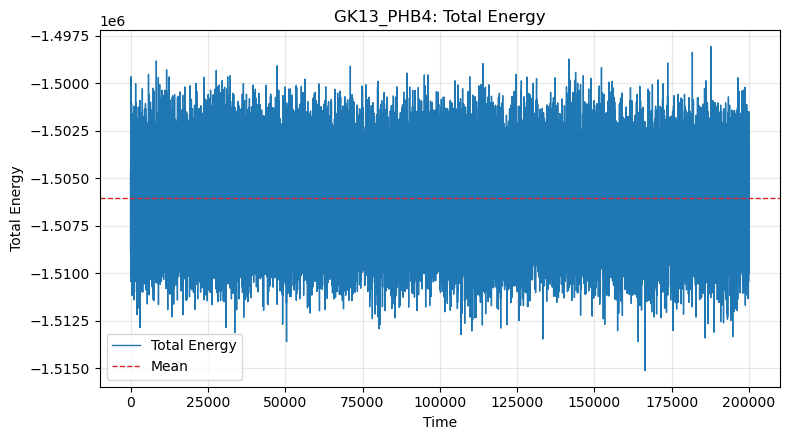

Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/total_energy.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/total_energy.png


In [3]:
TOTAL_ENERGY_XVG = OUTPUT_DIR / "total_energy.xvg"
TOTAL_ENERGY_CSV = OUTPUT_DIR / "total_energy.csv"
TOTAL_ENERGY_PNG = OUTPUT_DIR / "total_energy.png"


def run_gmx_energy(selection_name: str) -> subprocess.CompletedProcess:
    if TOTAL_ENERGY_XVG.exists():
        TOTAL_ENERGY_XVG.unlink()

    command = [
        "gmx",
        "energy",
        "-f",
        str(EDR_PATH),
        "-o",
        str(TOTAL_ENERGY_XVG),
    ]
    return subprocess.run(
        command,
        input=f"{selection_name}\n0\n",
        text=True,
        capture_output=True,
        cwd=OUTPUT_DIR,
        check=False,
    )


if shutil.which("gmx") is None:
    raise RuntimeError("Could not find the `gmx` executable on PATH. Load GROMACS before running this cell.")

attempts = []
energy_selection = None
for candidate in ("Total-Energy", "Total Energy"):
    result = run_gmx_energy(candidate)
    attempts.append((candidate, result.returncode, result.stdout, result.stderr))
    if result.returncode == 0 and TOTAL_ENERGY_XVG.exists() and TOTAL_ENERGY_XVG.stat().st_size > 0:
        energy_selection = candidate
        break

if energy_selection is None:
    details = []
    for candidate, returncode, stdout, stderr in attempts:
        details.append(
            f"Selection: {candidate}\n"
            f"Return code: {returncode}\n"
            f"STDOUT tail:\n{stdout[-2000:]}\n"
            f"STDERR tail:\n{stderr[-2000:]}"
        )
    raise RuntimeError("gmx energy failed for both Total-Energy and Total Energy.\n\n" + "\n\n".join(details))

print(f"Extracted GROMACS energy term: {energy_selection}")
print(f"Wrote: {TOTAL_ENERGY_XVG}")


def read_xvg_two_column(path: Path) -> pd.DataFrame:
    rows = []
    with path.open() as handle:
        for line in handle:
            stripped = line.strip()
            if not stripped or stripped.startswith(("#", "@")):
                continue
            parts = stripped.split()
            if len(parts) < 2:
                continue
            rows.append((float(parts[0]), float(parts[1])))
    if not rows:
        raise ValueError(f"No numeric two-column data were found in {path}")
    return pd.DataFrame(rows, columns=["time", "total_energy"])


energy_df = read_xvg_two_column(TOTAL_ENERGY_XVG)
energy_df.to_csv(TOTAL_ENERGY_CSV, index=False)

energy_std = energy_df["total_energy"].std(ddof=1)
print("First 5 rows:")
display(energy_df.head())
print(f"Min energy: {energy_df['total_energy'].min():.6g}")
print(f"Max energy: {energy_df['total_energy'].max():.6g}")
print(f"Standard deviation: {energy_std:.6g}")
print(f"First value: {energy_df['total_energy'].iloc[0]:.6g}")
print(f"Last value: {energy_df['total_energy'].iloc[-1]:.6g}")

if pd.isna(energy_std):
    warnings.warn("Total Energy standard deviation is undefined because fewer than two data points were parsed.", RuntimeWarning)
elif np.isclose(energy_std, 0.0, atol=1e-12, rtol=1e-9):
    warnings.warn("Total Energy standard deviation is zero or nearly zero. Check that the selected energy term is correct.", RuntimeWarning)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(energy_df["time"], energy_df["total_energy"], linewidth=1.0, label="Total Energy")
ax.axhline(energy_df["total_energy"].mean(), color="tab:red", linestyle="--", linewidth=1.0, label="Mean")
ax.set_xlabel("Time")
ax.set_ylabel("Total Energy")
ax.set_title(f"{SYSTEM_NAME}: Total Energy")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(TOTAL_ENERGY_PNG, dpi=200)
plt.show()

print(f"Wrote: {TOTAL_ENERGY_CSV}")
print(f"Wrote: {TOTAL_ENERGY_PNG}")

## 5. Catalytic residue detection

In [4]:
try:
    import MDAnalysis as mda
    from MDAnalysis.lib.distances import distance_array
except ImportError as exc:
    raise ImportError("MDAnalysis is required for the contact-map section. Install or load it before running this notebook.") from exc


def catalytic_residue_definitions(system_name: str) -> list[tuple[str, int]]:
    if system_name.startswith("GK13"):
        return [
            ("SER", 139),
            ("ASP", 195),
            ("HIS", 227),
        ]
    if system_name.startswith("ANC45"):
        return [
            ("SER", 138),
            ("ASP", 194),
            ("HIS", 226),
        ]
    raise ValueError(
        f"No catalytic-residue definition is configured for SYSTEM_NAME={system_name!r}. "
        "Expected a name starting with 'GK13' or 'Anc45'."
    )


def load_universe_with_fallback():
    attempts = []
    for topology_path in (TPR_PATH, GRO_PATH):
        if not topology_path.exists():
            attempts.append(f"{topology_path}: file does not exist")
            continue
        try:
            universe = mda.Universe(str(topology_path), str(XTC_PATH))
            return universe, topology_path
        except Exception as exc:
            attempts.append(f"{topology_path}: {type(exc).__name__}: {exc}")
    raise RuntimeError("MDAnalysis could not load the trajectory with TPR_PATH or GRO_PATH.\n" + "\n".join(attempts))


u, topology_used = load_universe_with_fallback()
print(f"Loaded topology: {topology_used}")
print(f"Loaded trajectory: {XTC_PATH}")
print(f"Atoms: {u.atoms.n_atoms}")
print(f"Frames: {len(u.trajectory)}")

catalytic_residues = catalytic_residue_definitions(SYSTEM_NAME)
catalytic_residues

/opt/homebrew/Caskroom/miniconda/base/envs/ipha_clean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded topology: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/step6.2_npt.tpr
Loaded trajectory: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/step7_production.xtc
Atoms: 137384
Frames: 2001


[('SER', 139), ('ASP', 195), ('HIS', 227)]

In [5]:
CATALYTIC_RESIDUES_USED_CSV = OUTPUT_DIR / "catalytic_residues_used.csv"

HISTIDINE_RESNAMES = {"HIS", "HID", "HIE", "HIP", "HSD", "HSE", "HSP"}
COMPATIBLE_RESNAMES = {
    "SER": {"SER"},
    "ASP": {"ASP"},
    "HIS": HISTIDINE_RESNAMES,
}
SIDECHAIN_ATOMS = {
    "SER": {"OG"},
    "ASP": {"OD1", "OD2"},
    "HIS": {"ND1", "NE2"},
}

protein_atoms = u.select_atoms("protein")
if len(protein_atoms) == 0:
    raise ValueError("MDAnalysis selection 'protein' returned no atoms. Check that the topology contains recognised protein residue names.")


def find_catalytic_residue(expected_resname: str, expected_resid: int):
    expected_resname = expected_resname.upper()
    compatible_names = COMPATIBLE_RESNAMES[expected_resname]
    same_resid = [residue for residue in protein_atoms.residues if int(residue.resid) == expected_resid]
    if not same_resid:
        raise ValueError(
            f"Expected catalytic residue {expected_resname}{expected_resid} was not found. "
            "Residue numbering may not match the topology."
        )
    compatible = [residue for residue in same_resid if residue.resname.upper() in compatible_names]
    if not compatible:
        observed = ", ".join(sorted({f"{res.resname}{res.resid}" for res in same_resid}))
        raise ValueError(
            f"Residue ID {expected_resid} was found as {observed}, not expected {expected_resname}. "
            "Residue numbering may not match the topology."
        )
    if len(compatible) > 1:
        observed = ", ".join(f"{res.resname}{res.resid} index={res.ix}" for res in compatible)
        raise ValueError(f"Multiple protein residues match {expected_resname}{expected_resid}: {observed}")
    return compatible[0]


def select_required_sidechain_atoms(residue, expected_resname: str):
    required_names = SIDECHAIN_ATOMS[expected_resname]
    selected_atoms = residue.atoms.select_atoms("name " + " ".join(sorted(required_names)))
    found_names = {atom.name.upper() for atom in selected_atoms}
    missing = sorted(required_names - found_names)
    if missing:
        raise ValueError(
            f"Missing required catalytic side-chain atom(s) {missing} in {residue.resname}{residue.resid}. "
            "Check atom naming in the topology before calculating distances."
        )
    return selected_atoms


catalytic_sites = []
catalytic_rows = []

for expected_resname, expected_resid in catalytic_residues:
    residue = find_catalytic_residue(expected_resname, expected_resid)
    analysis_atoms = select_required_sidechain_atoms(residue, expected_resname)
    expected_label = f"{expected_resname}{expected_resid}"
    atom_names_used = " ".join(atom.name for atom in analysis_atoms)
    catalytic_sites.append(
        {
            "label": expected_label,
            "residue": residue,
            "analysis_atoms": analysis_atoms,
        }
    )
    catalytic_rows.append(
        {
            "expected_label": expected_label,
            "actual_resname": residue.resname,
            "actual_resid": int(residue.resid),
            "atom_names_used": atom_names_used,
            "n_atoms": int(analysis_atoms.n_atoms),
        }
    )

catalytic_df = pd.DataFrame(catalytic_rows)
catalytic_df.to_csv(CATALYTIC_RESIDUES_USED_CSV, index=False)
display(catalytic_df)
print(f"Wrote: {CATALYTIC_RESIDUES_USED_CSV}")

,expected_label,actual_resname,actual_resid,atom_names_used,n_atoms
0,SER139,SER,139,OG,1
1,ASP195,ASP,195,OD1 OD2,2
2,HIS227,HSD,227,ND1 NE2,2


Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/catalytic_residues_used.csv


## 6. LIG polymer atom detection

In [6]:
POLYMER_RESIDUE_ATOM_INSPECTION_CSV = OUTPUT_DIR / "polymer_residue_atom_inspection.csv"
POLYMER_GROUPS_USED_CSV = OUTPUT_DIR / "polymer_groups_used.csv"

polymer_atoms = u.select_atoms(POLYMER_SELECTION)
if len(polymer_atoms) == 0:
    raise ValueError(
        "The polymer selection returned no atoms. Check POLYMER_SELECTION and the topology residue names. "
        f"Current selection: {POLYMER_SELECTION!r}"
    )

polymer_residues = list(polymer_atoms.residues)
polymer_inspection_rows = [
    {
        "resid": int(residue.resid),
        "resname": residue.resname,
        "atom_names": " ".join(atom.name for atom in residue.atoms),
        "n_atoms": int(residue.atoms.n_atoms),
    }
    for residue in polymer_residues
]
polymer_inspection_df = pd.DataFrame(polymer_inspection_rows)
polymer_inspection_df.to_csv(POLYMER_RESIDUE_ATOM_INSPECTION_CSV, index=False)

print(f"Polymer selection: {POLYMER_SELECTION}")
print(f"Polymer atoms: {polymer_atoms.n_atoms}")
print(f"Polymer residues: {len(polymer_residues)}")
display(polymer_inspection_df)
print(f"Wrote: {POLYMER_RESIDUE_ATOM_INSPECTION_CSV}")


def normalise_override_resids(value, label: str):
    if value is None:
        return None
    if isinstance(value, int):
        return [value]
    try:
        return [int(resid) for resid in value]
    except TypeError as exc:
        raise TypeError(f"{label} must be None, an int, or an iterable of residue IDs.") from exc


def infer_lig_atom_order_groups(lig_atoms):
    n_atoms = lig_atoms.n_atoms
    if n_atoms < 3:
        raise ValueError("At least three LIG atoms are needed to infer polymer_head, polymer_main, and polymer_tail.")
    first_cut = n_atoms // 3
    second_cut = (2 * n_atoms) // 3
    if first_cut == 0 or second_cut <= first_cut or second_cut >= n_atoms:
        raise ValueError("Could not split LIG atoms into non-empty head, main, and tail groups.")
    return {
        "polymer_head": lig_atoms[:first_cut],
        "polymer_main": lig_atoms[first_cut:second_cut],
        "polymer_tail": lig_atoms[second_cut:],
    }


def select_polymer_atoms_by_resids(group_resids, group_name: str):
    group_resids = [int(resid) for resid in group_resids]
    polymer_atom_resids = polymer_atoms.resids.astype(int)
    group_atoms = polymer_atoms[np.isin(polymer_atom_resids, np.array(group_resids, dtype=int))]
    if len(group_atoms) == 0:
        raise ValueError(f"{group_name} contains no LIG atoms for residue IDs {group_resids}.")
    return group_atoms

manual_groups = {
    "polymer_head": normalise_override_resids(POLYMER_HEAD_RESIDS, "POLYMER_HEAD_RESIDS"),
    "polymer_main": normalise_override_resids(POLYMER_MAIN_RESIDS, "POLYMER_MAIN_RESIDS"),
    "polymer_tail": normalise_override_resids(POLYMER_TAIL_RESIDS, "POLYMER_TAIL_RESIDS"),
}

if all(value is None for value in manual_groups.values()):
    polymer_groups = infer_lig_atom_order_groups(polymer_atoms)
    group_source = "automatic_lig_atom_order_thirds"
elif all(value is not None for value in manual_groups.values()):
    polymer_groups = {
        group_name: select_polymer_atoms_by_resids(group_resids, group_name)
        for group_name, group_resids in manual_groups.items()
    }
    group_source = "manual_override"
else:
    raise ValueError(
        "Set all three polymer group overrides, or leave all three as None: "
        "POLYMER_HEAD_RESIDS, POLYMER_MAIN_RESIDS, POLYMER_TAIL_RESIDS."
    )

polymer_group_rows = []

for group_name, group_atoms in polymer_groups.items():
    group_resids = list(dict.fromkeys(int(resid) for resid in group_atoms.resids))
    polymer_group_rows.append(
        {
            "group_name": group_name,
            "resids": " ".join(str(resid) for resid in group_resids),
            "n_atoms": int(group_atoms.n_atoms),
            "atom_names": " ".join(atom.name for atom in group_atoms),
        }
    )

polymer_groups_df = pd.DataFrame(polymer_group_rows)
polymer_groups_df.to_csv(POLYMER_GROUPS_USED_CSV, index=False)
print(f"Polymer group detection: {group_source}")
print("Final polymer groups used for distance calculation:")
display(polymer_groups_df)
print(f"Wrote: {POLYMER_GROUPS_USED_CSV}")

Polymer selection: resname LIG
Polymer atoms: 51
Polymer residues: 1


,resid,resname,atom_names,n_atoms
0,246,LIG,O1 C1 C2 C3 C4 O2 O3 C5 C6 C7 C8 O4 O5 C9 C10 ...,51


Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/polymer_residue_atom_inspection.csv
Polymer group detection: automatic_lig_atom_order_thirds
Final polymer groups used for distance calculation:


,group_name,resids,n_atoms,atom_names
0,polymer_head,246,17,O1 C1 C2 C3 C4 O2 O3 C5 C6 C7 C8 O4 O5 C9 C10 ...
1,polymer_main,246,17,O6 O7 C13 C14 C15 C16 O8 O9 H1 H2 H3 H4 H5 H6 ...
2,polymer_tail,246,17,H10 H11 H12 H13 H14 H15 H16 H17 H18 H19 H20 H2...


Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/polymer_groups_used.csv


## 7. Contact calculation

For each frame, calculate the minimum distance between each catalytic residue side-chain atom set and each LIG polymer group: `polymer_head`, `polymer_main`, and `polymer_tail`.

By default, the LIG atoms are split by topology order: beginning = `polymer_head`, middle = `polymer_main`, end = `polymer_tail`.

MDAnalysis normally loads GROMACS coordinates in Å internally, so the cutoff is used directly as `CUTOFF_ANGSTROM = 3.0`.

The contact heatmap depends strongly on this cutoff, so the minimum-distance and mean-distance matrices are saved as more diagnostic summaries alongside contact occupancy.

In [7]:
CATALYTIC_TRIAD_POLYMER_DISTANCES_CSV = OUTPUT_DIR / "catalytic_triad_polymer_distances.csv"
CATALYTIC_TRIAD_POLYMER_CONTACT_OCCUPANCY_CSV = OUTPUT_DIR / "catalytic_triad_polymer_contact_occupancy.csv"
CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_CSV = OUTPUT_DIR / "catalytic_triad_polymer_min_distance.csv"
CATALYTIC_TRIAD_POLYMER_MEAN_DISTANCE_CSV = OUTPUT_DIR / "catalytic_triad_polymer_mean_distance.csv"

catalytic_order = [site["label"] for site in catalytic_sites]
polymer_group_order = ["polymer_head", "polymer_main", "polymer_tail"]

distance_rows = []

for ts in u.trajectory:
    for site in catalytic_sites:
        for group_name in polymer_group_order:
            group_atoms = polymer_groups[group_name]
            distances = distance_array(site["analysis_atoms"].positions, group_atoms.positions, box=ts.dimensions)
            min_distance = float(np.min(distances))
            distance_rows.append(
                {
                    "frame": int(ts.frame),
                    "time_ps": float(ts.time),
                    "catalytic_residue": site["label"],
                    "polymer_group": group_name,
                    "min_distance_A": min_distance,
                    "contact": min_distance <= CUTOFF_ANGSTROM,
                }
            )

distances_df = pd.DataFrame(distance_rows)
if distances_df.empty:
    raise ValueError("No distance rows were calculated. Check that the trajectory contains frames.")

distances_df.to_csv(CATALYTIC_TRIAD_POLYMER_DISTANCES_CSV, index=False)

occupancy_matrix = (
    distances_df.groupby(["catalytic_residue", "polymer_group"])["contact"]
    .mean()
    .unstack("polymer_group")
    .reindex(index=catalytic_order, columns=polymer_group_order)
)
occupancy_matrix.to_csv(CATALYTIC_TRIAD_POLYMER_CONTACT_OCCUPANCY_CSV)

min_distance_matrix = (
    distances_df.groupby(["catalytic_residue", "polymer_group"])["min_distance_A"]
    .min()
    .unstack("polymer_group")
    .reindex(index=catalytic_order, columns=polymer_group_order)
)
min_distance_matrix.to_csv(CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_CSV)

mean_distance_matrix = (
    distances_df.groupby(["catalytic_residue", "polymer_group"])["min_distance_A"]
    .mean()
    .unstack("polymer_group")
    .reindex(index=catalytic_order, columns=polymer_group_order)
)
mean_distance_matrix.to_csv(CATALYTIC_TRIAD_POLYMER_MEAN_DISTANCE_CSV)

print(f"Analysed frames: {distances_df['frame'].nunique()}")
display(distances_df.head())
print("Contact occupancy matrix:")
display(occupancy_matrix)
print("Minimum distance matrix (Å):")
display(min_distance_matrix)
print("Mean distance matrix (Å):")
display(mean_distance_matrix)
print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_DISTANCES_CSV}")
print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_CONTACT_OCCUPANCY_CSV}")
print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_CSV}")
print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_MEAN_DISTANCE_CSV}")

Analysed frames: 2001


,frame,time_ps,catalytic_residue,polymer_group,min_distance_A,contact
0,0,0.0,SER139,polymer_head,3.713444,False
1,0,0.0,SER139,polymer_main,3.131587,False
2,0,0.0,SER139,polymer_tail,2.696464,True
3,0,0.0,ASP195,polymer_head,7.755092,False
4,0,0.0,ASP195,polymer_main,7.249723,False


Contact occupancy matrix:


polymer_group,polymer_head,polymer_main,polymer_tail
catalytic_residue,,,
SER139,0.012494,0.056972,0.187406
ASP195,0.000000,0.000000,0.000000
HIS227,0.001499,0.031984,0.033983


Minimum distance matrix (Å):


polymer_group,polymer_head,polymer_main,polymer_tail
catalytic_residue,,,
SER139,2.651882,1.777521,1.701619
ASP195,5.044422,4.328265,4.398887
HIS227,2.836147,1.892669,1.849348


Mean distance matrix (Å):


polymer_group,polymer_head,polymer_main,polymer_tail
catalytic_residue,,,
SER139,23.837829,23.130228,23.197488
ASP195,25.573355,24.594879,24.725478
HIS227,24.044063,23.176600,23.392906


Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_distances.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_contact_occupancy.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_min_distance.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_mean_distance.csv


## 8. Contact and minimum-distance heatmaps

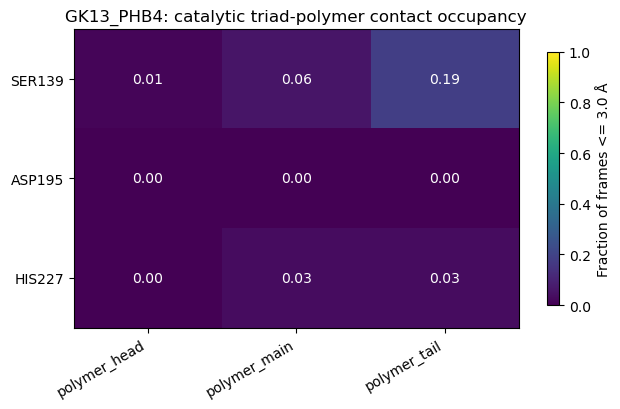

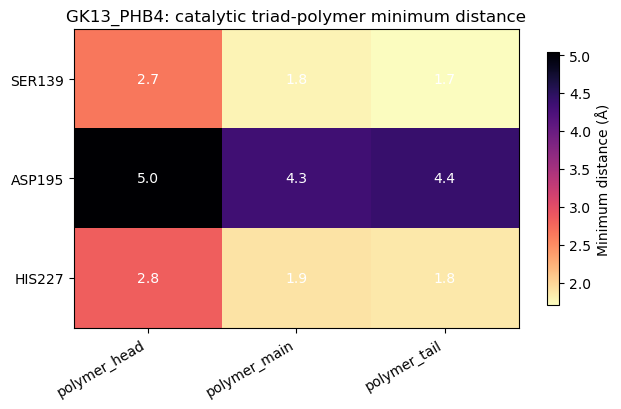

Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_contact_heatmap.png
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_PHB4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_min_distance_heatmap.png


In [8]:
CATALYTIC_TRIAD_POLYMER_CONTACT_HEATMAP_PNG = OUTPUT_DIR / "catalytic_triad_polymer_contact_heatmap.png"
CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_HEATMAP_PNG = OUTPUT_DIR / "catalytic_triad_polymer_min_distance_heatmap.png"

fig, ax = plt.subplots(figsize=(6.5, 4.2))
image = ax.imshow(occupancy_matrix.to_numpy(dtype=float), vmin=0.0, vmax=1.0, cmap="viridis", aspect="auto")
ax.set_xticks(np.arange(len(polymer_group_order)))
ax.set_xticklabels(polymer_group_order, rotation=30, ha="right")
ax.set_yticks(np.arange(len(catalytic_order)))
ax.set_yticklabels(catalytic_order)
ax.set_title(f"{SYSTEM_NAME}: catalytic triad-polymer contact occupancy")

for row_index, residue_label in enumerate(catalytic_order):
    for column_index, group_name in enumerate(polymer_group_order):
        value = occupancy_matrix.loc[residue_label, group_name]
        text_color = "white" if value < 0.55 else "black"
        ax.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", color=text_color)

colorbar = fig.colorbar(image, ax=ax, shrink=0.85)
colorbar.set_label(f"Fraction of frames <= {CUTOFF_ANGSTROM:.1f} Å")
fig.tight_layout()
fig.savefig(CATALYTIC_TRIAD_POLYMER_CONTACT_HEATMAP_PNG, dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.2))
min_values = min_distance_matrix.to_numpy(dtype=float)
image = ax.imshow(min_values, cmap="magma_r", aspect="auto")
ax.set_xticks(np.arange(len(polymer_group_order)))
ax.set_xticklabels(polymer_group_order, rotation=30, ha="right")
ax.set_yticks(np.arange(len(catalytic_order)))
ax.set_yticklabels(catalytic_order)
ax.set_title(f"{SYSTEM_NAME}: catalytic triad-polymer minimum distance")

for row_index, residue_label in enumerate(catalytic_order):
    for column_index, group_name in enumerate(polymer_group_order):
        value = min_distance_matrix.loc[residue_label, group_name]
        ax.text(column_index, row_index, f"{value:.1f}", ha="center", va="center", color="white")

colorbar = fig.colorbar(image, ax=ax, shrink=0.85)
colorbar.set_label("Minimum distance (Å)")
fig.tight_layout()
fig.savefig(CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_HEATMAP_PNG, dpi=200)
plt.show()

print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_CONTACT_HEATMAP_PNG}")
print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_HEATMAP_PNG}")

## 9. Short interpretation

In [9]:
print("Short interpretation")
print("- Contact occupancy is the fraction of analysed frames where the catalytic residue is within the cutoff of a polymer group.")
print("- The contact heatmap depends strongly on the cutoff, so inspect the minimum-distance and mean-distance matrices before interpreting occupancy.")
print("- Treat Total Energy as a first diagnostic only; in NVT/NPT it is not expected to be perfectly conserved, but strong drift or sudden jumps suggest a problem.")

Short interpretation
- Contact occupancy is the fraction of analysed frames where the catalytic residue is within the cutoff of a polymer group.
- The contact heatmap depends strongly on the cutoff, so inspect the minimum-distance and mean-distance matrices before interpreting occupancy.
- Treat Total Energy as a first diagnostic only; in NVT/NPT it is not expected to be perfectly conserved, but strong drift or sudden jumps suggest a problem.
